In [1]:
import sys
import os
import copy
from os import path, getcwd
import warnings
import torch
import gc

from scipy.stats import norm, multivariate_normal
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output

SAMPLE_SIZE = 2048
ROOT = 'C:/Mega/trunk/master-thesis'
DATA_PATH = 'F:/master_data/'
CUDA = True

# code paths
sys.path.append(path.join(ROOT, 'src/models'))
sys.path.append(path.join(ROOT, 'src/exp'))
sys.path.append(path.join(ROOT, 'src/common'))

%reload_ext autoreload
%autoreload 2

from inflation.sampling_density_stuff import *
from inflation.jupyter_helper import *
from misc.naming import *

folder = 'small_var_range/inflation-10.26_15-53-40-sphere-exp'
folder = 'small_var_range/inflation-10.29_06-54-06-sphere-exp_no_scaling'
NAMING_ADDITION = ''
if 'no_scaling' in folder:
    NAMING_ADDITION = 'no_scaling_'

CHECKPOINTS_ROOT = DATA_PATH + f'/checkpoints/{folder}/nf'
MODEL_SORTING = ('RealNVP', 'NICE')
DATASET_NAME = None
    
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
all_checkpoints = get_all_checkpoints(CHECKPOINTS_ROOT)
all_checkpoints_unsorted = all_checkpoints

all_checkpoints = sort_all_checkpoints(all_checkpoints, DATA_PATH)
dimensions, variances = get_all_dimensions_and_variances(all_checkpoints)

In [3]:
#dimensions = [100]

In [4]:
prog_per_dim = len(variances) * len(all_checkpoints)
prog_per_sig = len(all_checkpoints)

# to load some standard information
config = load_config(all_checkpoints['NICE'][dimensions[0]][variances[1]], DATA_PATH, verbose=False)
DATASET_NAME = config.dataset

all_models = dict()
true_data = dict()
total_eval_count = len(all_checkpoints) * len(dimensions) * len(variances)

for iDim, dimension in enumerate(dimensions):
    for iVar, var in enumerate(variances):
            
        for iModel, model in enumerate(all_checkpoints):
            progress = iDim * prog_per_dim + iVar * prog_per_sig + iModel + 1
            print('\r', f'Models evaluated: {progress} / {total_eval_count} ', end='')
            #print(dimension, var, model)        
        
            setdefault_multiple_depth(all_models, model, dimension, var)
            current_model = all_models[model][dimension][var]
            
            x_pd, z_pd = compute_sample_densities(all_checkpoints[model][dimension][var], DATA_PATH, SAMPLE_SIZE)
            current_model['x'], current_model['z'] = x_pd, z_pd
            
        gc.collect()
        torch.cuda.empty_cache()

 Models evaluated: 24 / 24 

-------------------
# Plotting

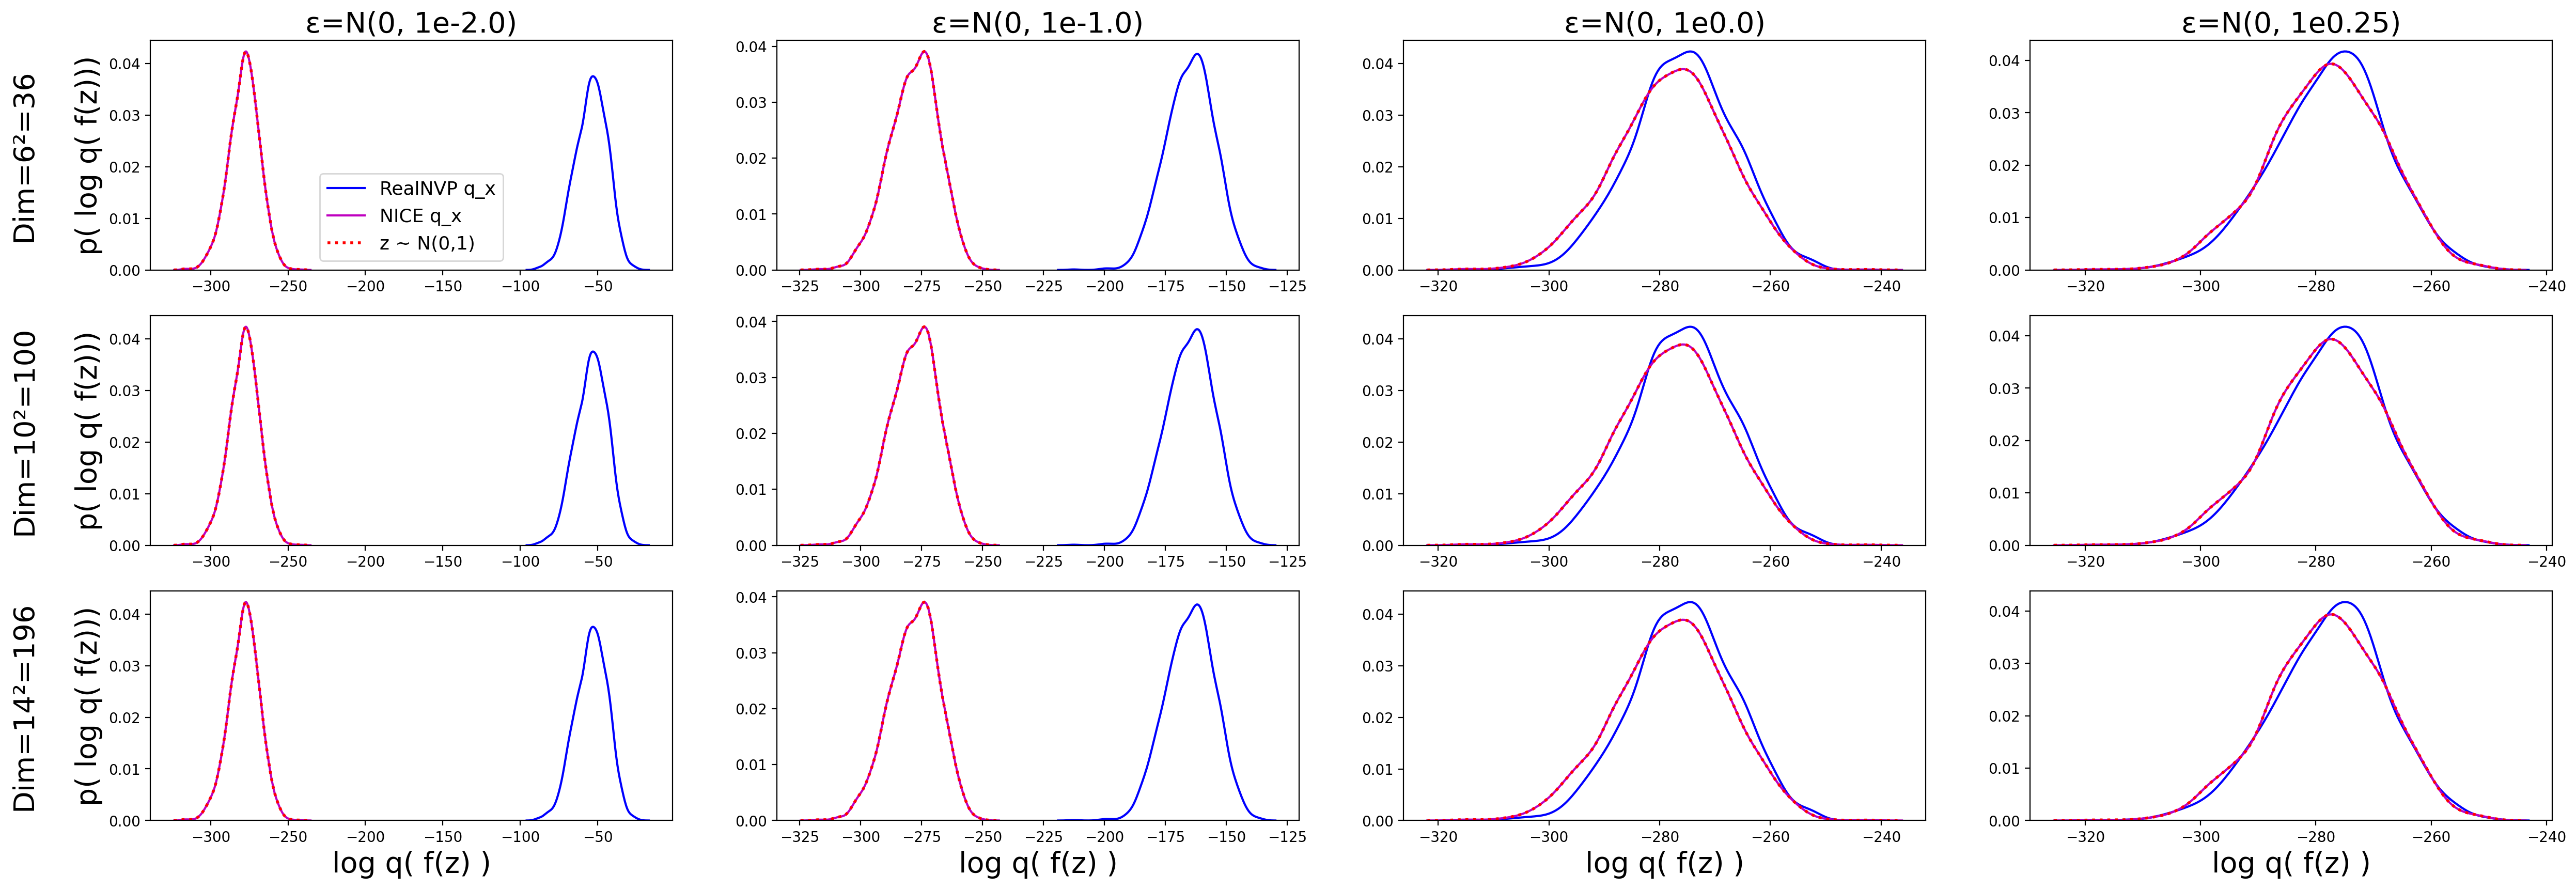

In [12]:
%matplotlib inline 

def plot_state_densities(centered, models):
    fig, axs = plt.subplots(nrows=len(dimensions), ncols=len(variances), squeeze=False, figsize=(30, 10), dpi=200, sharey=False)

    for iD, dim in enumerate(dimensions):
        for iS, var in enumerate(variances):
            
            #print(model, dim, var)
            for model in models:
                ax = axs[iD][iS]
                
                model_data = all_models[model][dimension][var]

                data = model_data['x'].copy()
                data = np.around(data, 1)
                if centered:
                    data -= data.mean()
                sns.distplot(data, label=f'{model} q_x', hist=False, color=get_model_color(model), ax=ax)
                
            # N(0,1) difference comes from different samples (i.e. NICE and RealNVP sample from different parts)
            data = model_data['z'].copy()
            if centered:
                data -= data.mean()
                
            sns.distplot(data, label=f'z ~ N(0,1)', hist=False, color='r', 
                        kde_kws= {'linewidth': 2, 'linestyle': ':'}, ax=ax)

            if (iD == 0 and iS == 0): # or idx == LLH_IDX:  # LLH_IDX for the means
                ax.legend(fontsize=LEGEND_FONT_SIZE)
            if iD == 0 and config.dataset != 'gauss':
                ax.set_title(f'ε=N(0, 1e{np.log10(var)})', size=20)
            if iS == 0:
                sdim = int(np.sqrt(dim))
                ax.set_ylabel(f'Dim={sdim}²={dim}\n\np( log q( f(z)))', size=20)
            else:
                ax.set_ylabel('')
            if iD == len(dimensions)-1:
                ax.set_xlabel('log q( f(z) )', size=20)
    return fig

fig = plot_state_densities(centered=False, models=MODEL_SORTING)
fig.savefig(f'sample_llh/{NAMING_ADDITION}pure_{DATASET_NAME}.png')

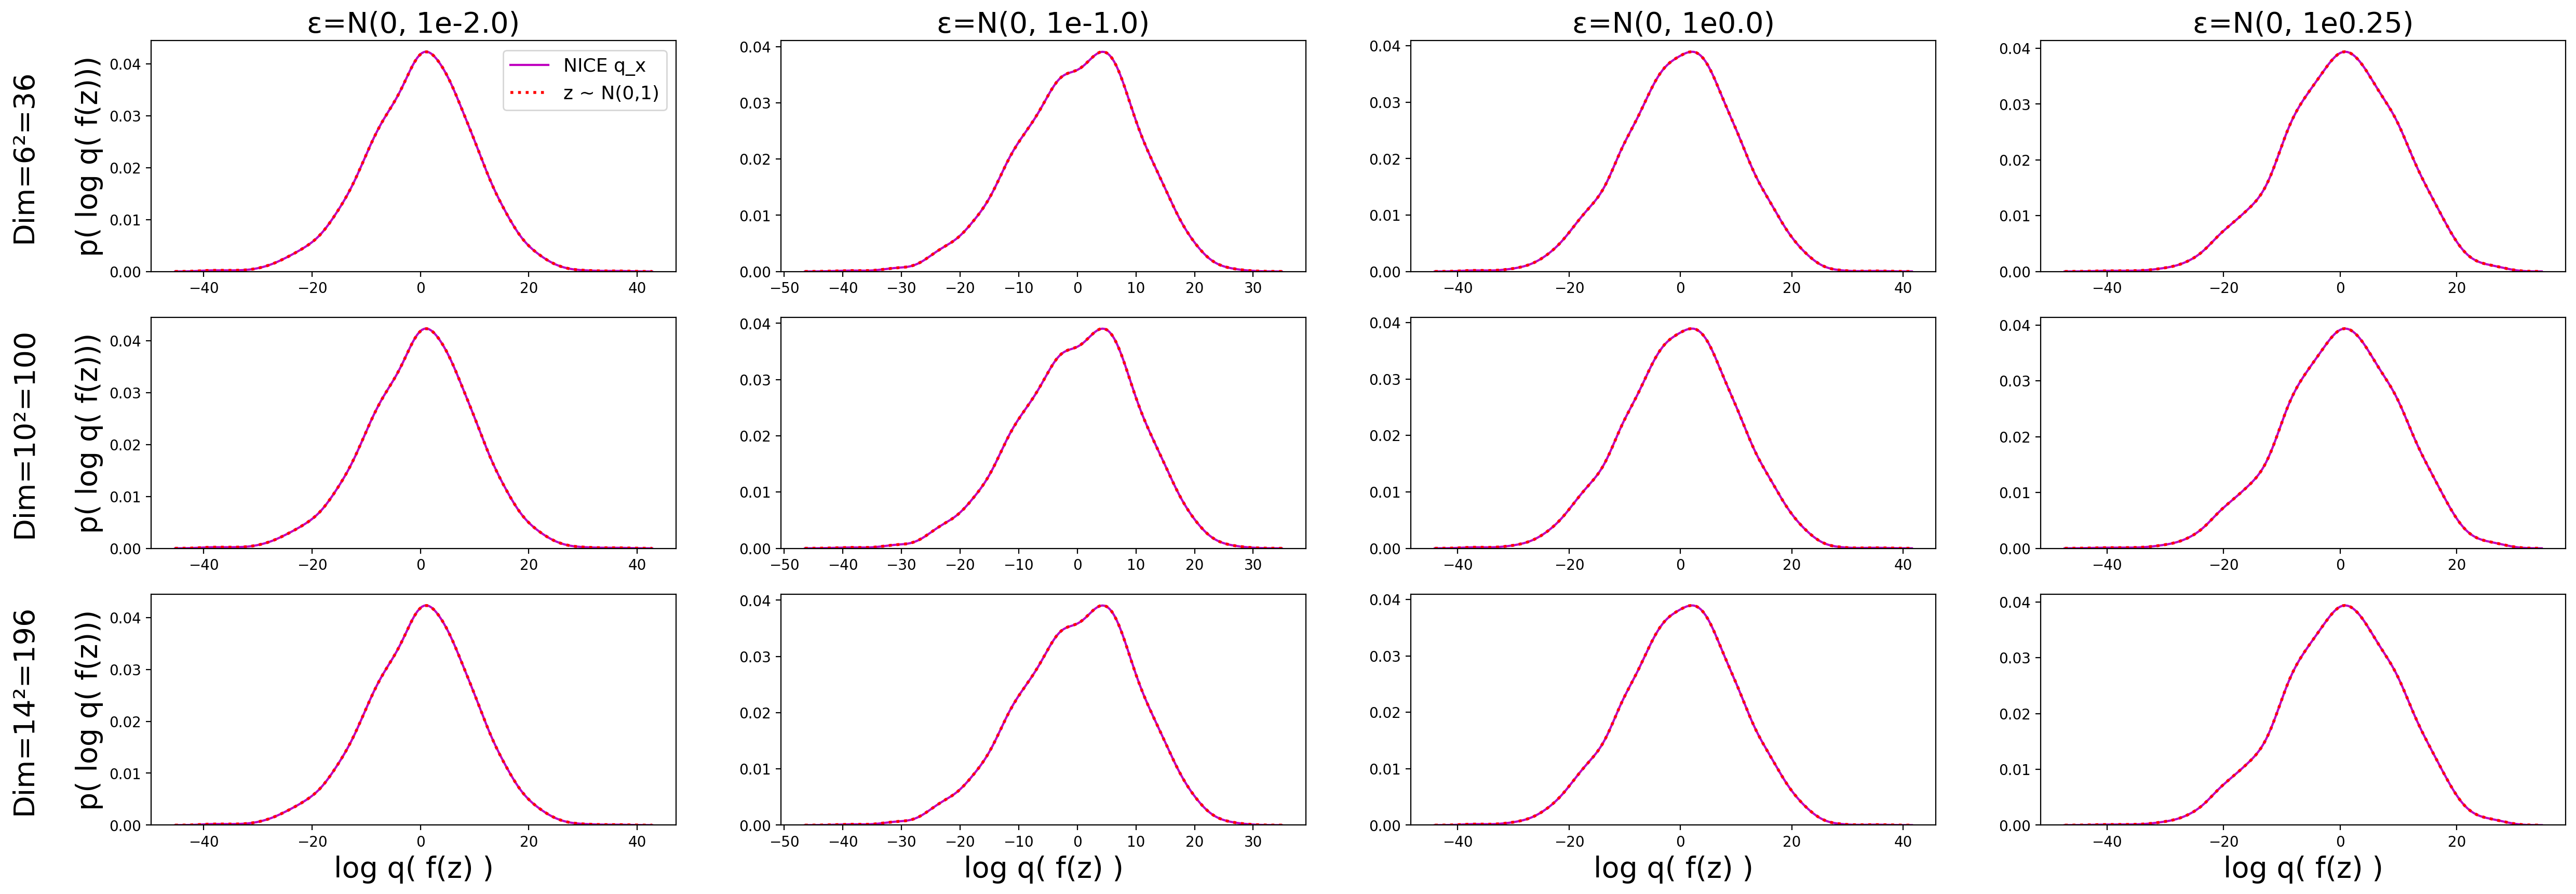

In [10]:
fig = plot_state_densities(centered=True, models=['NICE'])
fig.savefig(f'sample_llh/{NAMING_ADDITION}centered_NICE_{DATASET_NAME}.png')

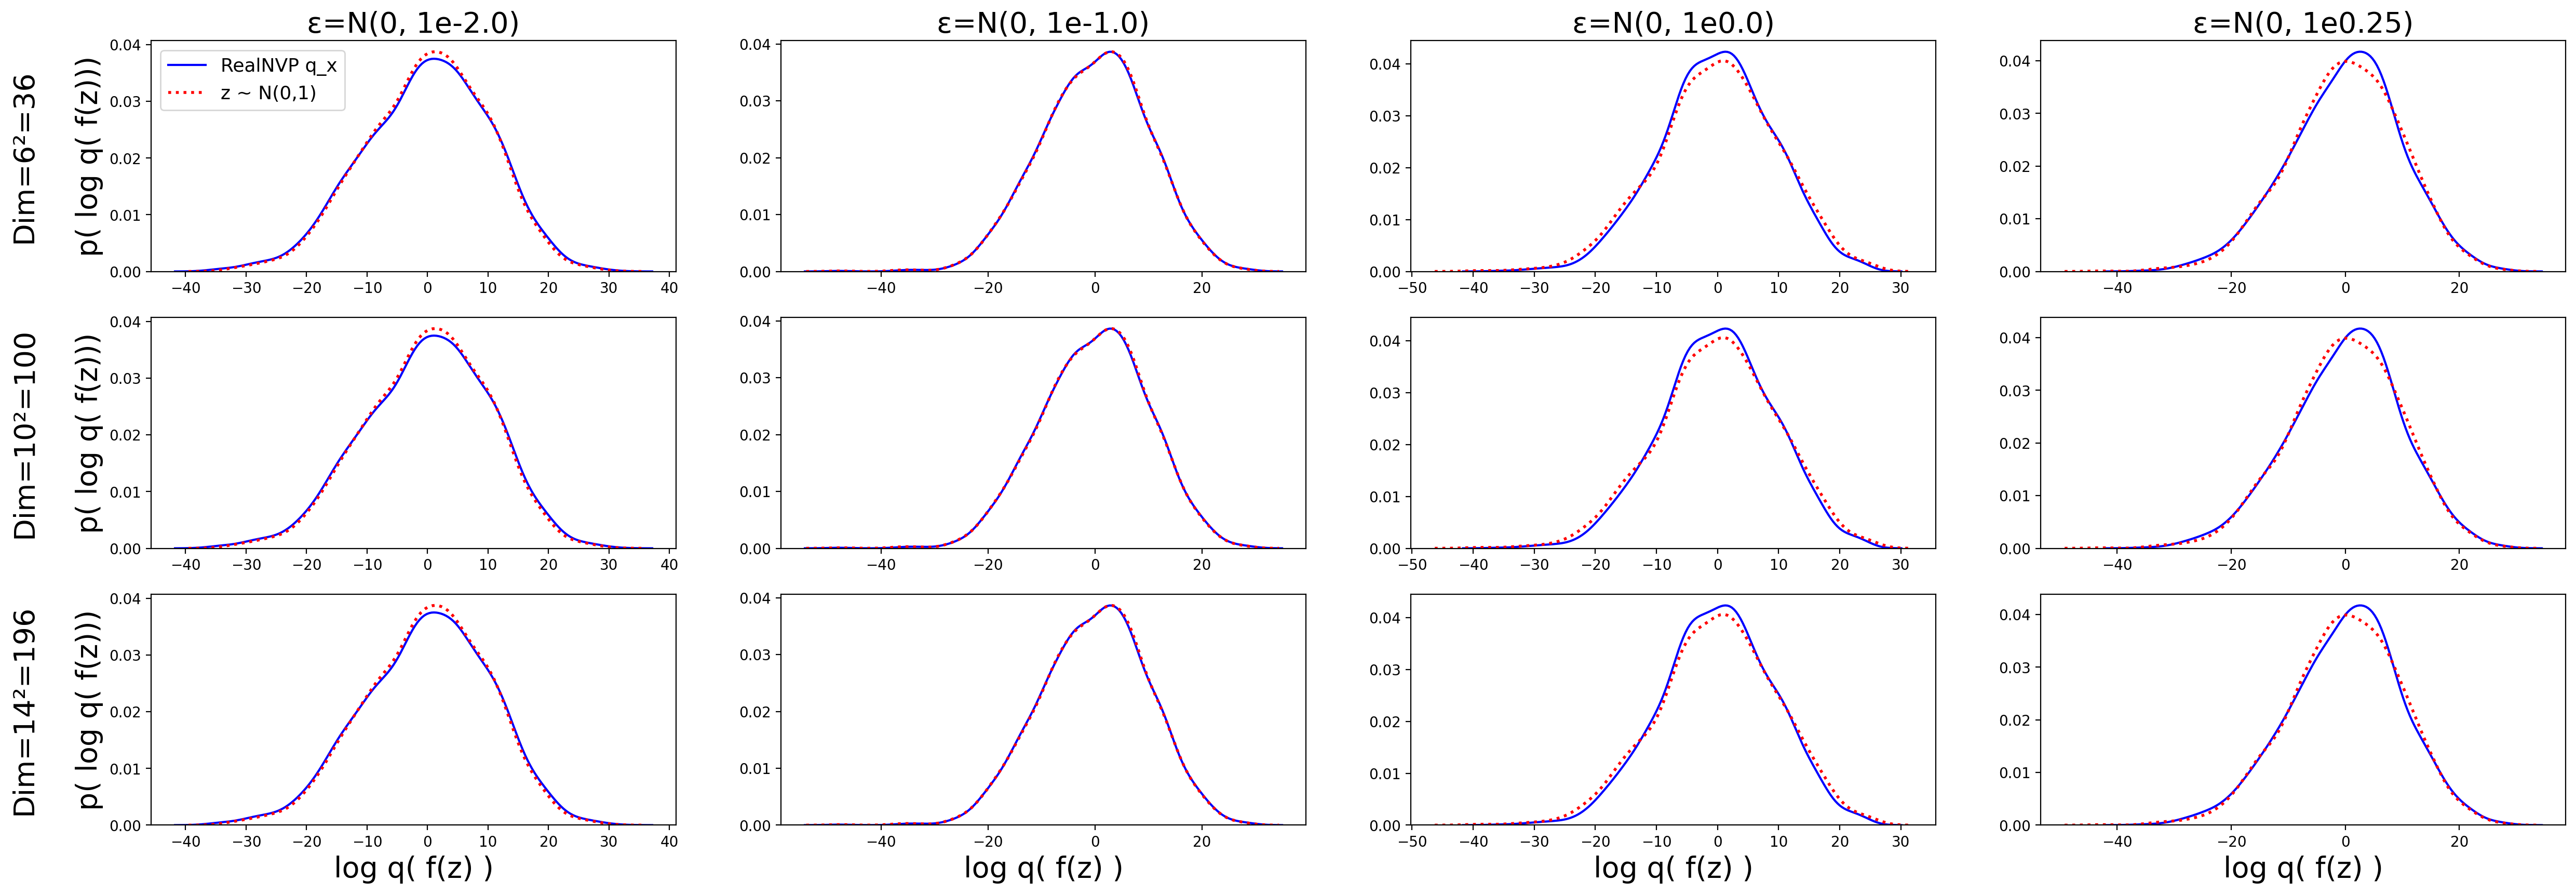

In [13]:
fig = plot_state_densities(centered=True, models=['RealNVP'])
fig.savefig(f'sample_llh/{NAMING_ADDITION}centered_RealNVP_{DATASET_NAME}.png')